# Step 5: Early warning signals

If the forcing slowly pushes the circulation toward a tipping point, can I see it coming in the fluctuations before the jump? Here I ramp the freshwater forcing past the fold with weak noise, and track the variance and lag-1 autocorrelation before the tip.

I load the libraries, scipy's `kendalltau`, and the Cessi functions from `src/models.py`. `%matplotlib inline` makes the figures show inside the notebook. The two `sys.path` lines let Python find `models.py`, which sits in the `src/` folder.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

import sys
sys.path.append("../src")   # models.py lives in the project's src/ folder

from models import cessi_tendency, cessi_equilibria, cessi_dpdy, cessi_fold_points

These are the parameter values: the ramp, the noise, how often I sample, the tipping threshold, and the window widths.

In [2]:
# ---------------- parameters ----------------
MU2 = 6.2                 # strength of advection relative to diffusion (Cessi's mu^2)
DIFFUSION_TIME_YR = 219   # one model time unit in years

P_START = 1.0             # forcing at the start of the ramp (strong state exists)
P_END = 1.4               # forcing at the end (past the fold at p = 1.296)
T_RAMP = 4000.0           # ramp duration in diffusion times (876,000 years); slow, so y tracks its branch
SIGMA = 0.04              # weak noise: small kicks that probe how strong the pull back is
DT = 0.01                 # Euler-Maruyama time step (diffusion times)
SEED = 7                  # random seed for reproducibility

SAMPLE_INTERVAL = 0.5     # keep one value every 0.5 diffusion times (~110 years), like a proxy record
TIP_THRESHOLD = 0.7       # y above this = tipped (strong branch never exceeds 0.43; weak branch is above ~0.9)
DETREND_WINDOW = 50.0     # width of the centred rolling mean that removes the slow trend (diffusion times)
STAT_WINDOW = 250.0       # width of the trailing window for variance and autocorrelation (diffusion times)
END_BUFFER = 10.0         # stop the analysis this long before the tip, so the escape itself is not counted as a warning

FIG_DIR = "../figures"
# --------------------------------------------

os.makedirs(FIG_DIR, exist_ok=True)

This function returns the strong equilibrium at a given forcing, or NaN past the fold where it no longer exists.

In [3]:
def strong_equilibrium(p, p_fold_strong):
    """y of the strong (small-y) equilibrium at forcing p, or NaN past the fold."""
    if p >= p_fold_strong:
        return np.nan
    return cessi_equilibria(p, MU2)[0]

This function gives a rolling mean centred on each point. I use it to remove the slow trend.

In [4]:
def rolling_mean_centred(x, half_width):
    """Mean of x over a window centred on each point (shorter at the ends)."""
    n = len(x)
    out = np.zeros(n)
    for i in range(n):
        start = max(0, i - half_width)
        stop = min(n, i + half_width + 1)
        out[i] = np.mean(x[start:stop])
    return out

This function computes the variance and lag-1 autocorrelation in trailing windows, so each value uses only data up to its own time. The test as a whole is still retrospective, as in Dakos et al. (2008): the detrending below is centred, and I cut the record using the known tip time.

In [5]:
def rolling_variance_and_ac1(x, width):
    """Variance and lag-1 autocorrelation in trailing windows.

    Each window ends at its own time, so it uses no later data.
    The value for window [i-width+1 ... i] is stored at index i. Earlier
    indices are NaN.
    """
    n = len(x)
    var = np.full(n, np.nan)
    ac1 = np.full(n, np.nan)
    for i in range(width - 1, n):
        window = x[i - width + 1:i + 1]
        var[i] = np.var(window)
        # Correlation between each value and the next one in the window
        ac1[i] = np.corrcoef(window[:-1], window[1:])[0, 1]
    return var, ac1

I compute the recovery rate r = dp/dy at the strong state, from p = 1.0 up to the fold. It says how fast a small nudge dies away.

In [6]:
# ---- 1. Fold point and theoretical recovery rate ----
y_fold_strong, p_fold_strong, _, _ = cessi_fold_points(MU2)

# Recovery rate = -(slope of the tendency) at the strong equilibrium = dp/dy.
# It says how fast a small nudge decays: e-folding time = 1 / rate.
p_theory = np.linspace(P_START, p_fold_strong, 400)
rate_theory = np.zeros(len(p_theory))
for i in range(len(p_theory)):
    y_s = strong_equilibrium(p_theory[i], p_fold_strong + 1e-12)
    rate_theory[i] = cessi_dpdy(y_s, MU2)

This is the noisy ramp: p rises from 1.0 to 1.4 over 4000 diffusion times, with the Euler-Maruyama method and a fixed seed.

In [7]:
# ---- 2. Ramp p with noise (Euler-Maruyama) ----
n_steps = int(round(T_RAMP / DT))
t = np.arange(n_steps + 1) * DT
p_of_t = P_START + (P_END - P_START) * t / T_RAMP

rng = np.random.default_rng(SEED)
kicks = SIGMA * np.sqrt(DT) * rng.standard_normal(n_steps)
y = np.zeros(n_steps + 1)
y[0] = strong_equilibrium(P_START, p_fold_strong)
for i in range(n_steps):
    y[i + 1] = y[i] + cessi_tendency(y[i], p_of_t[i], MU2) * DT + kicks[i]

The tip is the first time y goes above 0.7, which is between the two branches.

In [8]:
# ---- 3. Find the tipping time ----
i_tip = np.argmax(y > TIP_THRESHOLD)
if y[i_tip] <= TIP_THRESHOLD:
    raise RuntimeError("the system never tipped; make the ramp longer or end at larger p")
t_tip = t[i_tip]
p_tip = p_of_t[i_tip]

I keep one value every 0.5 diffusion times and stop 10 diffusion times before the tip, so the escape itself is not counted. I remove the slow trend, compute the rolling statistics, and measure their trend with Kendall's tau.

In [9]:
# ---- 4. Sample like a record and keep only the part before the tip ----
# The last few diffusion times before the threshold crossing are the
# escape itself (y climbing out of the valley). That is the tip, not a
# warning of it, so we stop a short buffer earlier.
i_end = i_tip - int(round(END_BUFFER / DT))
every = int(round(SAMPLE_INTERVAL / DT))
t_s = t[:i_end:every]
y_s = y[:i_end:every]
p_s = p_of_t[:i_end:every]

# Remove the slow trend. As p rises, the mean of y creeps up along the
# branch. That drift is not a fluctuation, and left in it would inflate
# the variance and push the autocorrelation toward 1 by itself.
half = int(round(0.5 * DETREND_WINDOW / SAMPLE_INTERVAL))
trend = rolling_mean_centred(y_s, half)
resid = y_s - trend

width = int(round(STAT_WINDOW / SAMPLE_INTERVAL))
var_roll, ac1_roll = rolling_variance_and_ac1(resid, width)

# Kendall's tau: +1 if a statistic only ever goes up in time, 0 if no trend
valid = ~np.isnan(var_roll)
tau_var, _ = kendalltau(t_s[valid], var_roll[valid])
tau_ac1, _ = kendalltau(t_s[valid], ac1_roll[valid])

For comparison, linear theory says variance = sigma^2/(2r) and lag-1 autocorrelation = exp(-r dt). r changes along the ramp, so I evaluate both at every sample, then average them over the same trailing windows as the data.

In [10]:
# ---- 5. What linear theory expects at each sample time ----
# Near a stable state the fluctuations behave like a random walk pulled
# back at the recovery rate r: variance = sigma^2 / (2 r), and lag-1
# autocorrelation over a gap D = exp(-r D). As r -> 0 both blow up.
# r is evaluated at the p of each sample.
var_theory = np.full(len(t_s), np.nan)
ac1_theory = np.full(len(t_s), np.nan)
for i in range(len(t_s)):
    y_eq = strong_equilibrium(p_s[i], p_fold_strong)
    if not np.isnan(y_eq):
        r = cessi_dpdy(y_eq, MU2)
        var_theory[i] = SIGMA ** 2 / (2 * r)
        ac1_theory[i] = np.exp(-r * SAMPLE_INTERVAL)

# Average the theory over each trailing window, as the data are. Using only the
# window's last point would overestimate the variance near the fold, where r
# changes a lot within one window.
var_theory_win = np.full(len(t_s), np.nan)
ac1_theory_win = np.full(len(t_s), np.nan)
for i in range(width - 1, len(t_s)):
    var_theory_win[i] = np.mean(var_theory[i - width + 1:i + 1])
    ac1_theory_win[i] = np.mean(ac1_theory[i - width + 1:i + 1])

This figure has three panels: y over time, the rolling variance and the rolling autocorrelation, with the tip marked.

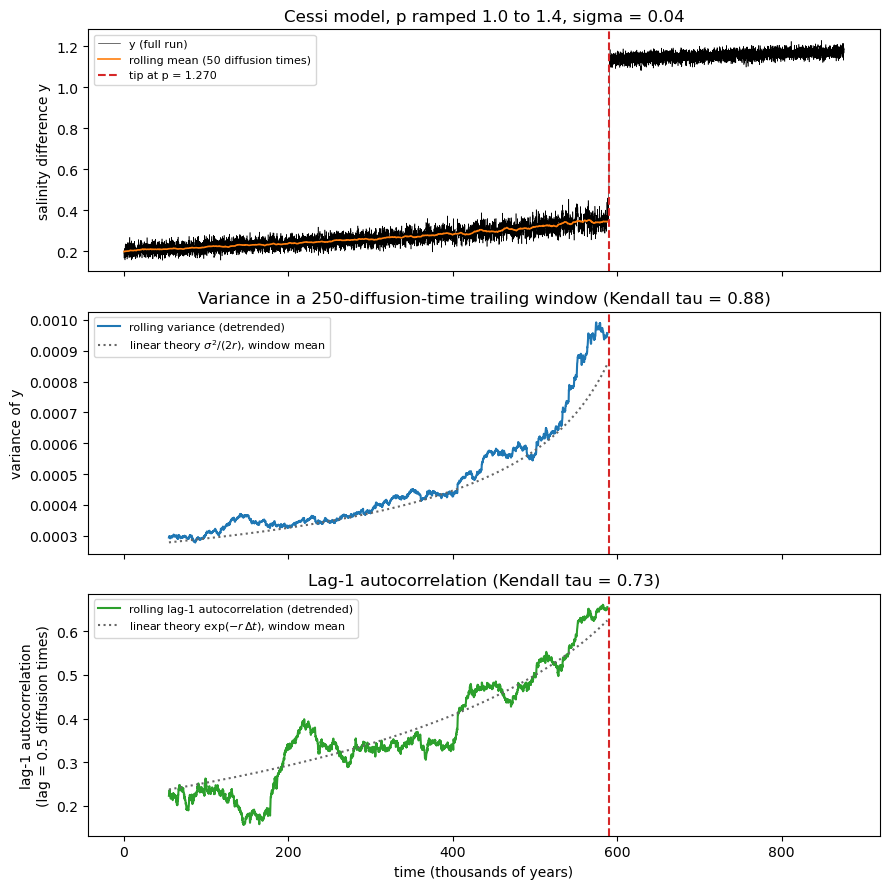

In [11]:
# ---- 6. Figure 1: three panels ----
to_kyr = DIFFUSION_TIME_YR / 1000.0
t_tip_kyr = t_tip * to_kyr
every_plot = 10    # thin the full-resolution series just for plotting
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

ax = axes[0]
ax.plot(t[::every_plot] * to_kyr, y[::every_plot], color="k", lw=0.4, label="y (full run)")
ax.plot(t_s * to_kyr, trend, color="tab:orange", lw=1.2, label=f"rolling mean ({DETREND_WINDOW:.0f} diffusion times)")
ax.axvline(t_tip_kyr, color="tab:red", ls="--", label=f"tip at p = {p_tip:.3f}")
ax.set_ylabel("salinity difference y")
ax.set_title(f"Cessi model, p ramped {P_START} to {P_END}, sigma = {SIGMA}")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
ax.plot(t_s * to_kyr, var_roll, color="tab:blue", label="rolling variance (detrended)")
ax.plot(t_s * to_kyr, var_theory_win, color="0.4", ls=":", label=r"linear theory $\sigma^2/(2r)$, window mean")
ax.axvline(t_tip_kyr, color="tab:red", ls="--")
ax.set_ylabel("variance of y")
ax.set_title(f"Variance in a {STAT_WINDOW:.0f}-diffusion-time trailing window (Kendall tau = {tau_var:.2f})")
ax.legend(fontsize=8, loc="upper left")

ax = axes[2]
ax.plot(t_s * to_kyr, ac1_roll, color="tab:green", label="rolling lag-1 autocorrelation (detrended)")
ax.plot(t_s * to_kyr, ac1_theory_win, color="0.4", ls=":", label=r"linear theory $\exp(-r\,\Delta t)$, window mean")
ax.axvline(t_tip_kyr, color="tab:red", ls="--")
ax.set_ylabel(f"lag-1 autocorrelation\n(lag = {SAMPLE_INTERVAL} diffusion times)")
ax.set_xlabel("time (thousands of years)")
ax.set_title(f"Lag-1 autocorrelation (Kendall tau = {tau_ac1:.2f})")
ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_early_warning_panels.png"), dpi=150)
plt.show()

This figure shows the recovery rate against p. It goes to zero at the fold, which is why the warnings appear.

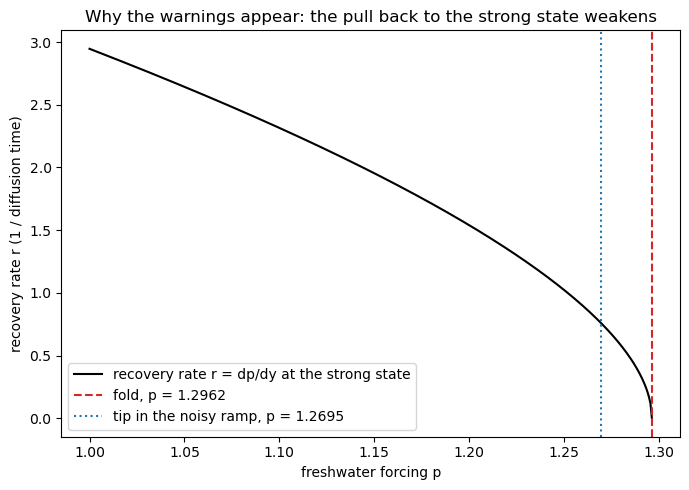

In [12]:
# ---- 7. Figure 2: recovery rate against p ----
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(p_theory, rate_theory, color="k", label="recovery rate r = dp/dy at the strong state")
ax.axvline(p_fold_strong, color="tab:red", ls="--", label=f"fold, p = {p_fold_strong:.4f}")
ax.axvline(p_tip, color="tab:blue", ls=":", label=f"tip in the noisy ramp, p = {p_tip:.4f}")
ax.set_xlabel("freshwater forcing p")
ax.set_ylabel("recovery rate r (1 / diffusion time)")
ax.set_title("Why the warnings appear: the pull back to the strong state weakens")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_recovery_rate.png"), dpi=150)
plt.show()

One run can be lucky. I repeat the whole analysis (same ramp, noise, sampling, detrending, windows and cut-off) for 100 runs with different random numbers. As a control, I also make 100 records at a fixed p = 1.1, where nothing approaches a fold, and analyse them in the same way. The function is checked against the single run above.

In [13]:
# ---- 8. The same test for 100 runs, plus a control with no fold ----
N_RUNS = 100
ENSEMBLE_SEED = 1000
P_CONTROL = 1.1          # control: fixed forcing, far from both folds
T_CONTROL = 2700.0       # control record length (diffusion times), about the time to the tip in the ramps

def early_warning_taus(y_sampled, t_sampled):
    """Kendall tau of the rolling variance and lag-1 autocorrelation, exactly as for the single run."""
    half_k = int(round(0.5 * DETREND_WINDOW / SAMPLE_INTERVAL))
    resid_k = y_sampled - rolling_mean_centred(y_sampled, half_k)
    var_k, ac1_k = rolling_variance_and_ac1(resid_k, width)
    ok = ~np.isnan(var_k)
    return kendalltau(t_sampled[ok], var_k[ok])[0], kendalltau(t_sampled[ok], ac1_k[ok])[0]

# Check: the function gives the same numbers as the single run above
assert np.allclose(early_warning_taus(y_s, t_s), (tau_var, tau_ac1))

def noisy_runs(p_values, n_runs, seed):
    """Euler-Maruyama for many runs at once. Keeps every `every`-th value of each run,
    and the first step at which each run goes above TIP_THRESHOLD (-1 if never)."""
    rng = np.random.default_rng(seed)
    n = len(p_values) - 1
    y_now = np.full(n_runs, strong_equilibrium(p_values[0], p_fold_strong))
    samples = np.zeros((n_runs, n // every + 1))
    samples[:, 0] = y_now
    first_above = np.full(n_runs, -1)
    for i in range(n):
        y_now = (y_now + cessi_tendency(y_now, p_values[i], MU2) * DT
                 + SIGMA * np.sqrt(DT) * rng.standard_normal(n_runs))
        if (i + 1) % every == 0:
            samples[:, (i + 1) // every] = y_now
        new = (first_above < 0) & (y_now > TIP_THRESHOLD)
        first_above[new] = i + 1
    return samples, first_above

# Ramp runs: same ramp as above, analysed up to END_BUFFER before each run's own tip
samples_ramp, tip_steps = noisy_runs(p_of_t, N_RUNS, ENSEMBLE_SEED)
t_samples = t[::every]
taus_ramp = []
p_tip_runs = []
for k in range(N_RUNS):
    if tip_steps[k] < 0:
        raise RuntimeError("a ramp run never tipped")
    i_stop = tip_steps[k] - int(round(END_BUFFER / DT))
    n_keep = (i_stop + every - 1) // every          # same samples as y[:i_stop:every]
    taus_ramp.append(early_warning_taus(samples_ramp[k, :n_keep], t_samples[:n_keep]))
    p_tip_runs.append(p_of_t[tip_steps[k]])
taus_ramp = np.array(taus_ramp)
p_tip_runs = np.array(p_tip_runs)

# Control runs: fixed p, whole record analysed
p_control = np.full(int(round(T_CONTROL / DT)) + 1, P_CONTROL)
samples_ctrl, _ = noisy_runs(p_control, N_RUNS, ENSEMBLE_SEED + 1)
t_ctrl = np.arange(samples_ctrl.shape[1]) * SAMPLE_INTERVAL
taus_ctrl = np.array([early_warning_taus(samples_ctrl[k], t_ctrl) for k in range(N_RUNS)])


This figure compares the Kendall tau of the 100 ramp runs with the 100 control runs.

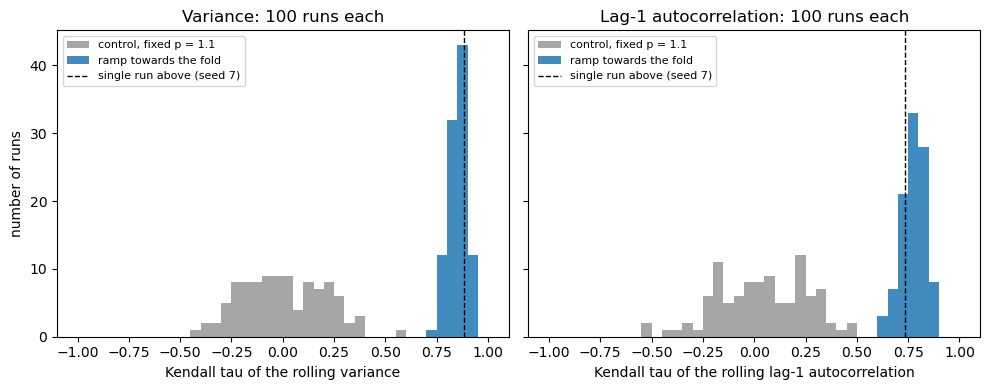

In [14]:
# ---- 9. Figure 3: Kendall tau for 100 ramp runs and 100 control runs ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bins = np.linspace(-1, 1, 41)
names = ["variance", "lag-1 autocorrelation"]
single = [tau_var, tau_ac1]
for j in range(2):
    ax = axes[j]
    ax.hist(taus_ctrl[:, j], bins=bins, color="0.65", label=f"control, fixed p = {P_CONTROL}")
    ax.hist(taus_ramp[:, j], bins=bins, color="tab:blue", alpha=0.85, label="ramp towards the fold")
    ax.axvline(single[j], color="k", ls="--", lw=1, label=f"single run above (seed {SEED})")
    ax.set_xlabel(f"Kendall tau of the rolling {names[j]}")
    ax.set_title(f"{names[j].capitalize()}: {N_RUNS} runs each")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("number of runs")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_early_warning_ensemble.png"), dpi=150)
plt.show()


Finally I print the tip, the recovery rates, the first and last window statistics with theory, Kendall's tau, and the summary of the 100 runs.

In [15]:
# ---- 10. Print the key numbers ----
print(f"Fold where the strong state ends: p = {p_fold_strong:.4f}")
print(f"Tip (y first above {TIP_THRESHOLD}): t = {t_tip:.1f} diffusion times "
      f"({t_tip * to_kyr:.0f} kyr), p = {p_tip:.4f}  ({p_fold_strong - p_tip:+.4f} before the fold)")
print()
print("Recovery rate r at the strong state (e-folding time 1/r):")
for p_show in [1.0, 1.1, 1.2, 1.25, 1.28, 1.29]:
    y_eq = strong_equilibrium(p_show, p_fold_strong)
    r = cessi_dpdy(y_eq, MU2)
    print(f"  p = {p_show:.2f}: r = {r:.3f}, 1/r = {1 / r:.2f} diffusion times ({DIFFUSION_TIME_YR / r:.0f} years)")
print()
first = width - 1
last = len(t_s) - 1
print(f"Rolling statistics ({STAT_WINDOW:.0f}-unit window, samples every {SAMPLE_INTERVAL} units, "
      f"analysis stops {END_BUFFER:.0f} units before the tip):")
print(f"  first window ends at p = {p_s[first]:.3f}: variance = {var_roll[first]:.2e} (theory {var_theory_win[first]:.2e}), "
      f"lag-1 AC = {ac1_roll[first]:.3f} (theory {ac1_theory_win[first]:.3f})")
print(f"  last window ends at p = {p_s[last]:.3f}:  variance = {var_roll[last]:.2e} (theory {var_theory_win[last]:.2e}), "
      f"lag-1 AC = {ac1_roll[last]:.3f} (theory {ac1_theory_win[last]:.3f})")
print(f"  Kendall tau: variance {tau_var:.3f}, lag-1 autocorrelation {tau_ac1:.3f}")
print("  (theory = linear theory averaged over the same window)")
print()
print(f"{N_RUNS} ramp runs: tip at p = {np.median(p_tip_runs):.4f} (median), "
      f"5-95% range {np.percentile(p_tip_runs, 5):.4f} to {np.percentile(p_tip_runs, 95):.4f}")
for j, name in enumerate(["variance", "lag-1 AC"]):
    print(f"  Kendall tau of {name:9s}: median {np.median(taus_ramp[:, j]):.3f}, "
          f"5-95% range {np.percentile(taus_ramp[:, j], 5):.3f} to {np.percentile(taus_ramp[:, j], 95):.3f}, "
          f"smallest {np.min(taus_ramp[:, j]):.3f}")
    print(f"  control (p = {P_CONTROL}):     median {np.median(taus_ctrl[:, j]):.3f}, "
          f"5-95% range {np.percentile(taus_ctrl[:, j], 5):.3f} to {np.percentile(taus_ctrl[:, j], 95):.3f}, "
          f"largest {np.max(taus_ctrl[:, j]):.3f}")

Fold where the strong state ends: p = 1.2962
Tip (y first above 0.7): t = 2695.3 diffusion times (590 kyr), p = 1.2695  (+0.0267 before the fold)

Recovery rate r at the strong state (e-folding time 1/r):
  p = 1.00: r = 2.947, 1/r = 0.34 diffusion times (74 years)
  p = 1.10: r = 2.316, 1/r = 0.43 diffusion times (95 years)
  p = 1.20: r = 1.540, 1/r = 0.65 diffusion times (142 years)
  p = 1.25: r = 1.023, 1/r = 0.98 diffusion times (214 years)
  p = 1.28: r = 0.580, 1/r = 1.72 diffusion times (378 years)
  p = 1.29: r = 0.349, 1/r = 2.86 diffusion times (627 years)

Rolling statistics (250-unit window, samples every 0.5 units, analysis stops 10 units before the tip):
  first window ends at p = 1.025: variance = 2.94e-04 (theory 2.79e-04), lag-1 AC = 0.223 (theory 0.238)
  last window ends at p = 1.268:  variance = 9.54e-04 (theory 8.56e-04), lag-1 AC = 0.655 (theory 0.625)
  Kendall tau: variance 0.880, lag-1 autocorrelation 0.735
  (theory = linear theory averaged over the same win